In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from sklearn.metrics import mean_squared_error

color_by_z = {1: "grey", 6: "cyan", 7: "blue", 8: "red", 16: "yellow"}
symbols_by_z = {1: "H", 6: "C", 7: "N", 8: "O", 16: "S"}

### Plot effective multipole moments

In [17]:
data = np.load("optimized_moments.npz")
data_dict = dict(zip(data.files, [data[f] for f in data.files]))
species_np = data_dict["species"]
ratios = data_dict["ratios"]

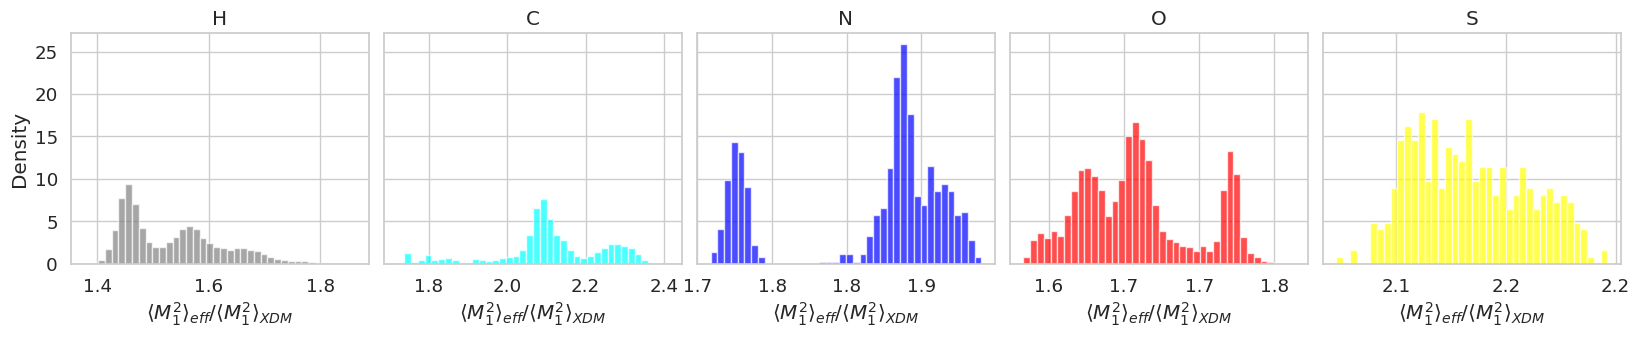

In [18]:
sns.set(style="whitegrid", font_scale=1.2)

z_values = sorted(color_by_z.keys())
fig, axes = plt.subplots(
    1, 
    len(z_values), 
    figsize=(4 * len(z_values), 3), 
    sharey=True,
    gridspec_kw={'wspace': 0.05} 
)

if len(z_values) == 1:
    axes = [axes]

for ax, z in zip(axes, z_values):
    mask = species_np == z
    ax.hist(
        ratios[mask],
        bins=40,
        alpha=0.7,
        color=color_by_z[z],
        density=True,
    )
    ax.set_title(f"{symbols_by_z[z]}")
    ax.set_xlabel(r"$\langle M_1^2 \rangle_{eff}  / \langle M_1^2 \rangle_{XDM}$")
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

axes[0].set_ylabel("Density")

# Shared y-axis label

plt.savefig("optimized_moments_histograms.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Plot results of training effective multipole moments

In [19]:
data_training = np.load("xdm_training_results.npz")

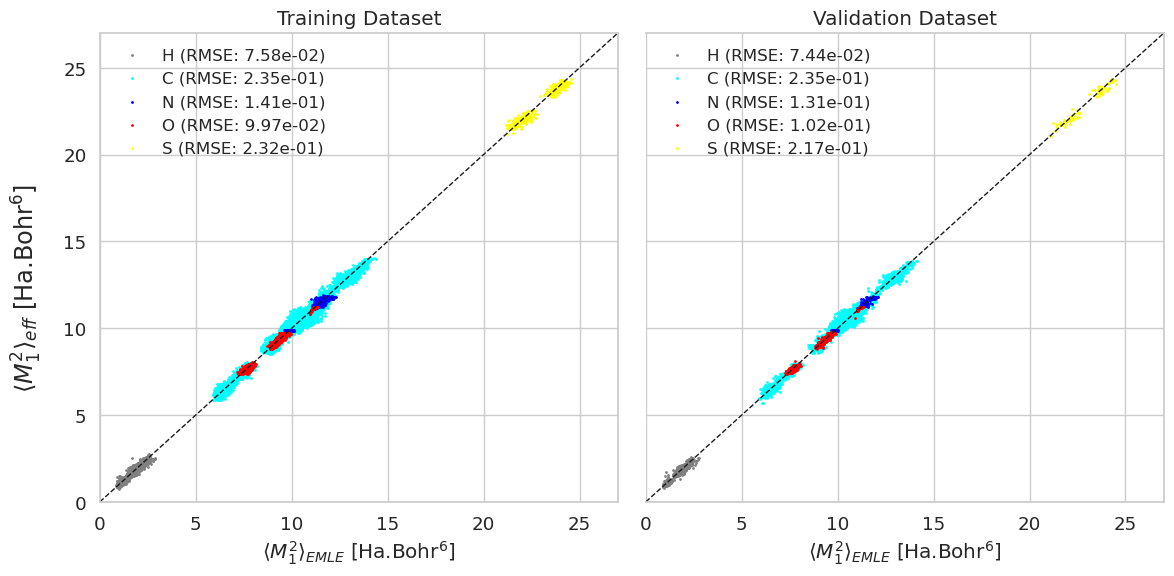

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set(style="whitegrid", font_scale=1.2)

xlabel = r"$\langle M_1^2 \rangle_{EMLE}$ [Ha.Bohr$^6$]"
ylabel = r"$\langle M_1^2 \rangle_{eff}$ [Ha.Bohr$^6$]"

datasets = [
    {
        "ax": axes[0],
        "y_true": data_training["m1_ref_train"],
        "y_pred": data_training["m1_pred"],
        "species": data_training["species_train"],
        "title": "Training Dataset",
    },
    {
        "ax": axes[1],
        "y_true": data_training["m1_ref_val"],
        "y_pred": data_training["m1_val"],
        "species": data_training["species_val"],
        "title": "Validation Dataset",
    },
]

for data in datasets:
    ax = data["ax"]
    species = data["species"]
    y_true = data["y_true"]
    y_pred = data["y_pred"]

    mask_global = y_true > 0
    rmse = np.sqrt(mean_squared_error(y_true[mask_global], y_pred[mask_global]))

    for z in color_by_z.keys():
        mask = (species == z) & (y_true > 0)
        z_rmse = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
        ax.scatter(
            y_true[mask],
            y_pred[mask],
            alpha=1,
            s=1,
            color=color_by_z[z],
            label=f"{symbols_by_z[z]} (RMSE: {z_rmse:.2e})",
        )

    ax.legend(fontsize=12, frameon=False)

    lims = [0, data_training["m1_ref_train"][data_training["m1_ref_train"] > 0].max() * 1.1]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel(xlabel)
    ax.set_title(data["title"])

fig.supylabel(ylabel)
axes[1].tick_params(left=False, labelleft=False)
axes[1].spines["left"].set_visible(False)
plt.subplots_adjust(wspace=0.05)
plt.tight_layout()
plt.savefig("m1_pred_vs_ref.pdf", dpi=300, bbox_inches="tight")
plt.show()